In [2]:
pip install -U -q "langchain[google-genai]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.4/236.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 4.7 MB/s eta 0:00:00


In [5]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict
from pydantic import BaseModel, Field

In [1]:
def print_workflow_info(workflow, app=None):
    """Prints comprehensive information about a LangGraph workflow."""
    print("WORKFLOW INFORMATION")
    print("====================")
    print(f"Nodes: {workflow.nodes}")
    print(f"Edges: {workflow.edges}")


    # Use getter method for finish points if available
    try:
        finish_points = workflow.finish_points
        print(f"Finish points: {finish_points}")
    except:
        try:
            # Alternative approaches
            print(f"Finish point: {workflow._finish_point}")
        except:
            print("Finish points attribute not directly accessible")

    if app:
        print("\nWorkflow Visualization:")
        from IPython.display import display
        display(app.get_graph().draw_png())

In [3]:
import os
from langchain.chat_models import init_chat_model
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

model = init_chat_model(
    model="gemini-2.5-flash",
    model_provider="google_genai"
)

### Workflow Pattern: Parallelization

Parallelization is a pattern where **multiple LLM tasks are executed at the same time** instead of one after another. This is useful when different parts of the task can be done **independently**, allowing for faster processing and better system throughput.

Think of it like a kitchen where one chef is chopping vegetables, another is boiling pasta, and another is baking — all at once. None of them need to wait for the other to finish.

In AI workflows, this means breaking a problem into parts and running them **in parallel**, then collecting and combining the outputs.

#### Use Cases:
- Summarizing different sections of a large document simultaneously
- Translating a batch of user messages at once
- Generating multiple variations of an ad copy or product description
- Running safety checks using different prompts and comparing outputs
- Ensembling results from different models or prompts for consensus

---

#### Parallelization Techniques:
1. **Format Diversity (Multi-Output Tasks)**  
   - Run the **same input** through **different prompt styles, languages, or output formats**  
   - Each LLM call produces a distinct kind of result in parallel  
   - Combine all outputs into a unified response  
   - *Example:* Translate a sentence into French, Spanish, and Japanese at the same time

2. **Task Splitting (Sectioning)**  
   - Divide a large input into smaller parts  
   - Run each part through the same task (for example, summarization) in parallel  
   - Merge the partial results for a final outcome  
   - *Example:* Summarize each paragraph of an article simultaneously

3. **Consensus Voting (Multi-Agent Evaluation)**  
   - Run the **same task** multiple times with different agents or prompt styles  
   - Compare the responses and choose the best one via ranking or majority vote  
   - *Example:* Ask 3 variations of a model to write a safe response and pick the most appropriate one


In [43]:
class State(TypedDict):
    text: str
    french: str
    spanish: str
    japanese: str
    combined_output: str

In [45]:
def translate_french(state: State) -> dict:
    response = model.invoke(f"Translate the following text to French:\n\n{state['text']}")
    return {"french": response.content.strip()}

In [46]:
def translate_spanish(state: State) -> dict:
    response = model.invoke(f"Translate the following text to Spanish:\n\n{state['text']}")
    return {"spanish": response.content.strip()}

In [47]:
def translate_japanese(state: State) -> dict:
    response = model.invoke(f"Translate the following text to Japanese:\n\n{state['text']}")
    return {"japanese": response.content.strip()}

In [48]:
def aggregator(state: State) -> dict:
    combined = f"Original Text: {state['text']}\n\n"
    combined += f"French: {state['french']}\n\n"
    combined += f"Spanish: {state['spanish']}\n\n"
    combined += f"Japanese: {state['japanese']}\n"
    return {"combined_output": combined}

In [49]:
graph = StateGraph(State)

In [50]:
graph.add_node("translate_french", translate_french)
graph.add_node("translate_spanish", translate_spanish)
graph.add_node("translate_japanese", translate_japanese)
graph.add_node("aggregator", aggregator)

In [51]:
# Connect parallel nodes from START
graph.add_edge(START, "translate_french")
graph.add_edge(START, "translate_spanish")
graph.add_edge(START, "translate_japanese")

In [52]:
# Connect all translation nodes to the aggregator
graph.add_edge("translate_french", "aggregator")
graph.add_edge("translate_spanish", "aggregator")
graph.add_edge("translate_japanese", "aggregator")

In [53]:
# Final node
graph.add_edge("aggregator", END)

In [54]:
# Compile the graph
app = graph.compile()

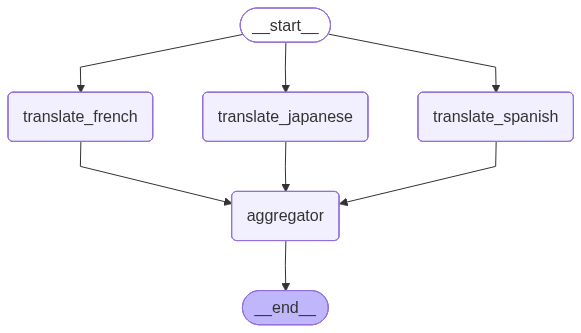

In [56]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [57]:
input_text = {
        "text": "Good morning! I hope you have a wonderful day."
}

result = app.invoke(input_text)

In [58]:
result

{'text': 'Good morning! I hope you have a wonderful day.',
 'french': 'Bonjour ! J\'espère que vous passez une excellente journée.\n\n*(You could also say: "J\'espère que vous avez une merveilleuse journée.")*',
 'spanish': '¡Buenos días! Espero que tengas un día maravilloso.\n\n*(You could also say "Espero que tenga un día maravilloso" if you want to be more formal or address multiple people.)*',
 'japanese': 'Here are a few options, depending on the nuance you want:\n\n**Option 1 (Common and natural):**\nおはようございます！良い一日を！\n*   *Ohayō gozaimasu! Yoi ichinichi o!*\n    *   "Good morning!"\n    *   "Have a good day!" (This is a very common way to express "I hope you have a good/wonderful day.")\n\n**Option 2 (Slightly more formal, explicitly "wonderful"):**\nおはようございます！素敵な一日をお過ごしください。\n*   *Ohayō gozaimasu! Suteki na ichinichi o osugoshi kudasai.*\n    *   "Good morning!"\n    *   "Please spend a wonderful/lovely day." (This politely conveys the wish.)\n\n**Option 3 (Emphasizing the wish 